# UCB

# 1. Problem Formulation

## 1.1 Environment 

- unstructured stochastic bandit with $1$-subgaussian reward

| Symbol | Definition |
|-------|------------|
| $k \in \mathbb{N}_+$  ($k < \infty$)| total number of arms  |
| $n \in \mathbb{N}_+$  | time horizon     |

## 1.2 Decision Variables

| Symbol | Definition |
|-------|------------|
| $A_t \in [k]$  |  arm chosen at step $t$    |

## 1.3 Rewards

Suppose $X_{i,t}$ is the reward of arm $i$ at step $t$, then define

$$
\mu_i := \mathbb{E}[X_{i,t}]
$$

then suppose for each arm $i$, $(X_{i,t})_{t \ge 1}$ i.i.d, and $X_{i,t} - \mu_i \sim subG(1)$





## 1.4 Regret 



the best-arm index is 

$$
i^* \in \arg\max\limits_{i \in [k]} \mu_i
$$

where if $|\arg\max\limits_{i \in [k]} \mu_i| >1$, then $i^*$ is uniquely chosen by tie-breaking rules.

then define $\Delta_i = \mu_{i^*} - \mu_i$


Then we have the regret:

$$
R_n := \sum_{i=1}^k \Delta_i \mathbb{E}[T_i(n)]
$$



# 2. Realted Math Tools

## 2.1 Inequallities

#### **2.1.1 Thr: Markov inequality and Chebyshev inequality**

For any random variable  $X \text{ and } \varepsilon > 0$,
the following holds:



(a) (Markov)
$ \mathbb{P}(|X| \ge \varepsilon) \le \frac{\mathbb{E}[|X|]}{\varepsilon}.$


(b) (Chebyshev)
$\mathbb{P}(|X - \mathbb{E}[X]| \ge \varepsilon) \le \frac{\mathrm{Var}(X)}{\varepsilon^2}.$



## **2.2 Subgaussian Related** 



#### **2.2.1 Def: Subgaussian; $subG(\sigma)$**

A random variable is subgaussian if its tail decays at least as fast as a Gaussian, specificly, a real-valued random variable $X$ with mean $\mu$ is called $\sigma-subgaussian$ $(X \sim subG(\sigma))$ if for $\forall \lambda \in \mathbb{R}$:

$$
\mathbb{E}[\exp(\lambda(X-\mu))] \le \exp\left(  \frac{\lambda^2 \sigma^2}{2}  \right)
$$

From now on we assume $X$ is centered

#### **2.2.2 Thr: concentrate inequality of $X \sim subG(\sigma)$**

If $X \sim subG(\sigma)$, then:

$$
\mathbb{P}(X\ge \epsilon) \le \exp\left( -\frac{\epsilon^2}{2\sigma^2}   \right)
$$

$proof.$

$$
\begin{align}
\mathbb{P}(X\ge \epsilon) &\overset{\forall \lambda \ge 0}{=} \mathbb{P}(\exp(\lambda X) \ge \exp(\lambda \epsilon)) \\
& \overset{\text{2.1.1.(a)}}{\le} \mathbb{E}[\exp(\lambda X)]\exp(-\lambda \epsilon) \\
& \overset{\text{2.2.1.}}{\le} \exp(\frac{\lambda^2 \sigma^2}{2}-\lambda \epsilon) \\
& \overset{\text{set}\lambda = \frac{\epsilon}{\sigma^2}}{=} \exp(-\frac{\epsilon^2}{2\sigma^2})
\end{align}
$$

complete the proof. $\blacksquare$

#### **2.2.3 Thr: Properties of $subG(\sigma)$ variables**

If $X \sim subG(\sigma)$, then 

- (a) $\mathbb{E}[X] = 0$

- (b) $\mathbb{V}[X] \le \sigma^2$

- (c) $cX \sim subG(|c|\sigma)$ for $\forall c \in \mathbb{R}$

- (d) $X_1 + X_2 \sim subG(\sqrt{\sigma_1^2 + \sigma_2^2})$ for $X_1 \sim subG(\sigma_1), X_2 \sim subG(\sigma_2)$

$proof.$ 

(a) 

by 2.1.1 Def, we have:

$$
\phi(\lambda) :=\log \mathbb{E}[\exp(\lambda X)] \le \frac{\lambda^2 \sigma^2}{2}
$$

$(\forall \lambda \in \mathbb{R})$

and since 

$$
\phi'(0) = \left.\frac{\mathbb{E}[X\exp(\lambda X)]}{\mathbb{E}[\exp(\lambda X)]}\right|_{\lambda=0} = \mathbb{E}[X]
$$

$$
\phi'(0) = \lim_{\lambda \rightarrow 0} \frac{\phi(\lambda) - \phi(0)}{\lambda - 0} \\
$$

we have: 

$$
\begin{align}
\mathbb{E}[X] &=  \lim_{\lambda \rightarrow 0} \frac{\phi(\lambda) - \phi(0)}{\lambda - 0} \\
&= \lim_{\lambda \rightarrow 0} \frac{\phi(\lambda)}{\lambda}
\end{align}
$$

and if $\lambda > 0$:

$$
\lim_{\lambda \rightarrow 0} \frac{\phi(\lambda)}{\lambda} \le \lim_{\lambda \rightarrow 0}\frac{\lambda \sigma^2}{2} = 0
$$

if $\lambda < 0$:

$$
\lim_{\lambda \rightarrow 0} \frac{\phi(\lambda)}{\lambda} \ge \lim_{\lambda \rightarrow 0}\frac{\lambda \sigma^2}{2} = 0
$$

thus $\mathbb{E}[X] = 0$;

similarly, we can prove that $\mathbb{V}[X] = \mathbb{E}[X^2] - 0 \le \sigma^2$

(c) and (d) can be easily obtained by the definition. $\blacksquare$ 

#### **2.2.4 Prop: Tail bound of $subG(\sigma)$**

If $X_i \overset{\text{i.i.d}}{\sim} subG(\sigma)$, then for $\forall \epsilon$

$$
\mathbb{P}(\hat{\mu} - \mu \ge \epsilon) \le \exp\left(-\frac{n\epsilon^2}{2\sigma^2} \right)
$$

$$
\mathbb{P}(\hat{\mu} - \mu \le -\epsilon) \le \exp\left(-\frac{n\epsilon^2}{2\sigma^2} \right)
$$

$proof.$ 
Easily derives from Thr 2.2.2 and Thr 2.2.3 .$\blacksquare$

And the inequality is equivalent to 

$$
\mathbb{P}\left(\hat{\mu} - \mu \ge \sqrt{\frac{2\sigma^2}{n}\log(1/\delta)}\right) \le \delta
$$

$$
\mathbb{P}\left(\hat{\mu} - \mu \le -\sqrt{\frac{2\sigma^2}{n}\log(1/\delta)}\right) \le \delta
$$

### **2.2.5 Thr: Hoeffding's Lemma**

If $X \overset{a.s.}{\in} [m,M]$ and $\mathbb{E}[X] = 0$, then for $\forall \lambda \in \mathbb{R}$:

$$
\mathbb{E}[\exp(\lambda X)] \le \exp\left(\frac{\lambda^2(M - m)^2}{8}  \right)
$$


### **2.2.6 Thr:$subG(\sigma)$**

(a) $\mathcal{N}(\mu, \sigma^2)$ is $\sigma$-subgaussian

(b) $Bern(p)$ is $\frac{1}{2}$-subgaussian

(c) Redemancher distribution: $\mathbb{P}(X = +1) = \mathbb{P}(X = -1) = \frac{1}{2}$ is 1-subgaussian

(d) Any bounded distribution: 

if $X \in [a,b]$, the 

$$
X - \mathbb{E}[X] \sim subG(\frac{b-a}{2})
$$


$proof.$

(a) let $Z \sim \mathcal{N}(0,1)$, then 

$$
\mathbb{E}[\exp (\lambda(X - \mu))] = \mathbb{E}[\exp(\lambda\sigma Z)] = \exp(\frac{(\lambda \sigma)^2}{2})
$$
thus $X$ is $\sigma$-subgaussian

(b)(c)(d): proved immediately by 2.2.5 Thr. $\blacksquare$

# 3. Algorithm I: UCB

![image_ucb1](materials/algo-ucb1.png)

![image_ucb1](materials/algo_ucb1_2.png)

## **3.1 Algorithm Rationale**

###  **(1) optimism**

"for not making regretful mistake, one should always expect the best possible outcome and give any potential opportunity a chance"

the algorithm just translate it into mathematical language: "At each time step, select the arm whose upper confidence bound on the expected reward is maximal."

Back to the algorithm, so our task is actually set to be "find the arm with maximal mean of reward", and by the optimism principle and 2.2.4 Prop, we've got the $\delta$-confidence upper bound of $subG(\sigma)$ reward before time step $t$, i.e. 

$$
\mathbb{P}\left(\mu_i \ge \hat{\mu}_i(t-1) + \sqrt{\frac{2\log(1/\delta)}{T_i(t-1)}}\right) \le \delta
$$

which says that the probability of the real mean $\mu_i$ exceeding $\hat{\mu}_i(t-1) + \sqrt{\frac{2\log(1/\delta)}{T_i(t-1)}}$ must be less or equal to $\delta$, hence we can set $\delta$ to be sufficiently small and say that the real parameter is few-likely to exceed the upper bound, and then use this upper bound as the optimism estimation of each candidate arm's mean reward. And notice that an arm that hasn't been tried before is the most worth trying one, thus its upper bound is set to be $\infty$.

and **one important problem  is how to find a may-exist optimal choice of $\delta$.**


## **3.2 Algorithm Analysis**



Let $\beta_i(t-1) := \sqrt{\frac{2\log(1/\delta)}{T_i(t-1)}}$

### **3.2.1 Thr: $\beta_i(t-1) \downarrow$ while $T_i(t-1) \uparrow$**

obviouly, since $\beta_i(t-1) \propto \sqrt{\frac{1}{T_i(t-1)}}$, this machanism is reasonable, since more information about this arm will be attained as the choosing times increase, thus one will be more and more certain about the estimation $\hat{\mu}_i$, then it is not fair for other arms to keep $\beta_i$ high as a kind of "New Player Protection" to arm $i$.

### **3.2.2 Thr:  $\beta_i(t-1) \downarrow$ while $\delta \uparrow$**

$$
\frac{\partial \beta_i(t-1)}{\partial \delta} = \frac{1}{2}\sqrt{\frac{2}{T_i(t-1)}}\frac{-1/\delta}{\sqrt{\log(1/\delta)}} < 0
$$

### **3.2.3 Thr:  upper bound of regret**

In the environment set in section 1, let $\delta = \frac{1}{n^2}$, then for $\forall v \in \mathcal{E}_{SG}^k(1)$, we have:

$$
R_n \le 3\sum_{i=1}^k \Delta_i + \sum_{i: \Delta_i >0}^k \frac{16\log(n)}{\Delta_i}
$$


> **📌Remark: A flaw of this bound**
>
> notice that there are $\frac{1}{\Delta_i}$ in the upper bound, then if $\exists i \in [k]$ s.t. $\Delta_i \rightarrow 0$, then $R_n \rightarrow \infty$, which will make this upper bound trivial.

$proof.$

See Appendix 1.

> **📌Remark: An inspiration of this bound**
>
> denote the right hand side of the inequality as $U(\Delta_1,\Delta_2, \cdots, \Delta_k)$

### **3.2.4 Prop: Thr 3.2.3 infers a sublinearity**

By 3.2.3 Thr, the regret upper bound is sublinear.

$proof.$

$$
\begin{align}
\lim_{n\rightarrow \infty} \frac{R_n}{n} &\le \lim_{n\rightarrow \infty}\frac{3\sum_{i=1}^k \Delta_i + \sum_{i=1}^k \frac{16\log(n)}{\Delta_i}}{n} \\
&= \lim_{n \rightarrow \infty} \left(\sum_{i=1}^k \frac{16}{\Delta_i}\right) \frac{\log(n)}{n} \\
&= 0
\end{align} \\
$$

and since $\frac{R_n}{n} \ge 0$, thus complete the proof. $\blacksquare$ 

### **3.2.5 Thr: another upper bound with no reciprocal gap terms**

If $\delta = \frac{1}{n^2}$, then for $\forall v \in \mathcal{E}_{SG}^k(1)$, we have:

$$
R_n \le 8 \sqrt{nk \log(n)} + 3 \sum_{i=1}^k \Delta_i
$$

$proof.$

see Appendix 2.

### **3.2.6 Prop: Thr 3.2.5 infers a sublinearity**

By 3.2.5 Thr, the regret upper bound is sublinear.

$proof.$


$$
\begin{align}
\lim_{n\rightarrow \infty} \frac{R_n}{n} &\le \lim_{n\rightarrow \infty}\frac{8 \sqrt{nk \log(n)} + 3 \sum_{i=1}^k \Delta_i}{n} \\
&= \lim_{n \rightarrow \infty} 8\sqrt{k}\sqrt{\frac{\log(n)}{n}} \\
&= 0
\end{align} \\
$$

and since $\frac{R_n}{n} \ge 0$, thus complete the proof. $\blacksquare$ 

## **3.3 Experiment- Bernoulli Bandit**

In our experiments, the rewards follow a Bernoulli distribution, which is 
$\frac{1}{2}$-subgaussian (by 2.2.6 Thr). For simplicity and consistency with the general theoretical framework, we treat the rewards as 1-subgaussian. Although this choice is conservative and leads to looser constants in the upper bound, it does not affect the order of the regret and keeps the presentation uniform.

### **3.3.1 Initialization**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### **(1) Environment**

In [4]:

class BernoulliBandit:
    """
    Bernoulli Multi-Armed Bandit Environment.

    Attributes:
        probs (np.ndarray): True reward probabilities for each arm.
        best_idx (int): Index of the optimal arm.
        best_prob (float): True reward probability of the optimal arm.
        counts (np.ndarray): Number of pulls per arm.
        values (np.ndarray): Empirical mean reward per arm.
        cumulative_reward (float): Total accumulated reward.
        cumulative_regret (float): Cumulative pseudo-regret.
        history (list): List of (arm, reward) tuples.
    """

    def __init__(self, K: int, probs: np.ndarray = None, random_probs: bool = True, seed: int | None = None):
        """
        Initialize the bandit with K arms.

        Args:
            K (int): Number of arms.
            probs (np.ndarray, optional): True reward probabilities for each arm.
            random_probs (bool, optional): Whether to generate random probabilities if probs is not provided.
            seed (int, optional): Random seed for reproducibility.
        """
        if K <= 0:
            raise ValueError("K must be positive.")

        self.rng = np.random.default_rng(seed)

        self.K = K
        if random_probs or probs is None:
            self.probs = self.rng.random(K)
        else:
            if len(probs) != K:
                raise ValueError("Length of probs must match K.")
            if not np.all((0 <= probs) & (probs <= 1)):
                raise ValueError("All probabilities must be in [0, 1].")
            self.probs = np.array(probs)
        self.best_idx = int(np.argmax(self.probs))
        self.best_prob = float(self.probs[self.best_idx])
        self.delta = self.best_prob - self.probs
        self.reset_stats()

    def step(self, k: int) -> int:
        """
        Pull arm k and return a Bernoulli reward.

        Args:
            k (int): Arm index.

        Returns:
            reward (int): 0 or 1.
        """
        if not (0 <= k < self.K):
            raise ValueError(f"Arm index {k} out of range (0-{self.K-1}).")

        # Generate Bernoulli reward
        reward = int(self.rng.random() < self.probs[k])

        # Update counts and empirical mean using incremental formula
        self.counts[k] += 1
        self.values[k] += (reward - self.values[k]) / self.counts[k]

        # Update cumulative reward
        self.cumulative_reward += reward

        # Update cumulative pseudo-regret:
        # sum_t (p* - p_{a_t})
        self.cumulative_regret += self.delta[k]

        # Store history
        self.history.append((k, reward))

        return reward

    def reset_stats(self):
        """Reset statistics while keeping the same true probabilities."""
        self.counts = np.zeros(self.K, dtype=int)
        self.values = np.zeros(self.K, dtype=float)
        self.cumulative_reward = 0.0
        self.cumulative_regret = 0.0
        self.history = []

    def plot_probabilities(self):
        """Visualize true reward probabilities."""
        plt.figure(figsize=(10, 6))
        plt.bar(range(self.K), self.probs)
        plt.axhline(self.best_prob, linestyle="--",
                    label=f"Best probability: {self.best_prob:.4f}")
        plt.xlabel("Arm index")
        plt.ylabel("Reward probability")
        plt.title("Bernoulli Bandit Reward Distribution")
        plt.legend()
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_performance(self):
        """Plot cumulative reward and cumulative pseudo-regret."""
        if not self.history:
            print("No history available.")
            return

        steps = np.arange(1, len(self.history) + 1)
        rewards = np.array([r for _, r in self.history])
        arms = np.array([a for a, _ in self.history])

        cumulative_rewards = np.cumsum(rewards)
        cumulative_regrets = np.cumsum(self.delta[arms])

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        ax1.plot(steps, cumulative_rewards, label="Cumulative reward")
        ax1.plot(steps, self.best_prob * steps, "--",
                 label="Optimal expected reward")
        ax1.set_ylabel("Reward")
        ax1.set_title("Cumulative Reward")
        ax1.legend()
        ax1.grid(True)

        ax2.plot(steps, cumulative_regrets, label="Cumulative pseudo-regret")
        ax2.set_xlabel("Time step")
        ax2.set_ylabel("Regret")
        ax2.set_title("Cumulative Regret")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    def report_all(self):
        """Print statistics and show performance plots."""
        print(f"\nCumulative reward: {self.cumulative_reward}")
        print(f"Cumulative pseudo-regret: {self.cumulative_regret:.4f}")

        df = pd.DataFrame({
            "Arm (0-based)": np.arange(self.K),
            "Pull count": self.counts,
            "True probability": np.round(self.probs, 4),
            "Empirical mean": np.round(self.values, 4),
        })

        print("\nBandit statistics:")
        print(df.to_string(index=False))

        self.plot_performance()

    def __str__(self):
        return (f"BernoulliBandit(K={self.K}, "
                f"best_arm={self.best_idx}, "
                f"best_prob={self.best_prob:.4f})")





#### **(2) Algorithm**

In [5]:
def ucb(bandit: BernoulliBandit, n: int, alpha: float):
    ub = np.array([float('inf')] * bandit.K)  # Initialize UCB values to infinity for exploration
    for t in range(1, n + 1):
        k = np.argmax(ub)  # Select arm with highest UCB
        bandit.step(k)
        ub[k] = bandit.values[k] + np.sqrt((2 * np.log(1/alpha)) / bandit.counts[k])  # Update UCB for arm k
    
    return bandit

then let's have a test, set time hirizon $n = 10^7$, total number of arms $k = 2$, then by the algorithm in this chapter, we have:


Cumulative reward: 1999649.0
Cumulative pseudo-regret: 540.9000

Bandit statistics:
 Arm (0-based)  Pull count  True probability  Empirical mean
             0        5409               0.1          0.0934
             1     9994591               0.2          0.2000


/tmp/ipykernel_9087/485636773.py:129: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/chenyuan/Projects/OnGoing/26_RL/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


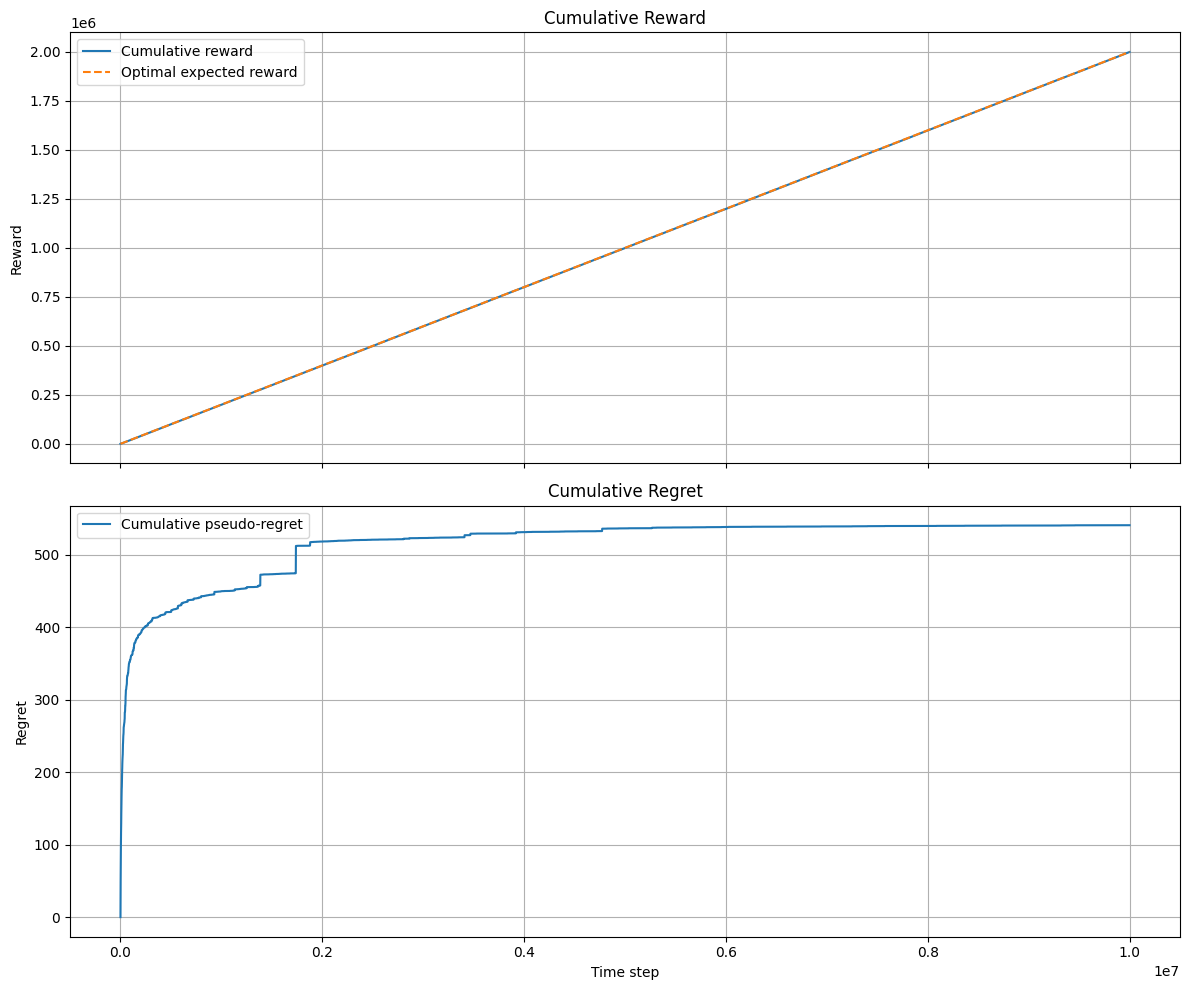

In [8]:
probs = np.array([0.1, 0.2])
k = len(probs) # number of arms
n_test = 10000000 # hirizon
alpha_test = 1/(n_test)**2 # confidence level

bandit = BernoulliBandit(K=k, probs=probs, random_probs=False, seed=42)

ucb(bandit, n_test, alpha_test).report_all()


the regret is indeed of a sublinear shape

### **3.3.2 Double-arms Bandit under different $\mu_1$ and $\Delta$**

We start at a double-arm situation where we can adjust the gap easily by one parameter $\Delta$, to be specific, choose $\mu_1 \in (0,1]$ and fix it, then $\mu_2 = \mu_1 - \Delta$, where $\Delta \in (0,\mu_1]$, now we are able to observe the performance (regret) of UCB algorithm under different situation

In [9]:

# =========================
# Config
# =========================
n_332 = 1000                 # horizon
delta_332 = 1 / (n_332**2)    # failure prob (passed into your ucb())
rounds_332 = 1000            # MC rounds

interval = "std"             # "std" or "ci95"
mu1_grid = np.arange(0.1, 1.0, 0.1)          # 0.1, ..., 0.9
Delta_step = 0.01

# =========================
# Run simulation
# regrets[(mu1, Delta)] = np.ndarray of shape (rounds_332,)
# =========================
regrets = {}

for mu_1 in mu1_grid:
    for Delta in np.arange(Delta_step, mu_1, Delta_step):
        mu_2 = mu_1 - Delta
        key = (float(mu_1), float(Delta))

        arr = np.empty(rounds_332, dtype=float)
        for r in range(rounds_332):
            bandit = BernoulliBandit(K=2, probs=np.array([mu_1, mu_2]), random_probs=False)
            arr[r] = float(ucb(bandit, n_332, delta_332).cumulative_regret)

        regrets[key] = arr

# =========================
# Helper: aggregate for one mu1
# =========================
def aggregate_for_mu1(regrets_dict, mu_1, interval="std"):
    deltas = sorted([Delta for (m, Delta) in regrets_dict.keys() if abs(m - mu_1) < 1e-12])
    if len(deltas) == 0:
        return None

    means, lo, hi = [], [], []
    for Delta in deltas:
        samples = regrets_dict[(float(mu_1), float(Delta))]
        m = samples.mean()
        s = samples.std(ddof=1)

        if interval == "ci95":
            half = 1.96 * s / np.sqrt(len(samples))
        else:  # "std"
            half = s

        means.append(m)
        lo.append(m - half)
        hi.append(m + half)

    return {
        "deltas": np.array(deltas, dtype=float),
        "mean": np.array(means, dtype=float),
        "lo": np.array(lo, dtype=float),
        "hi": np.array(hi, dtype=float),
    }




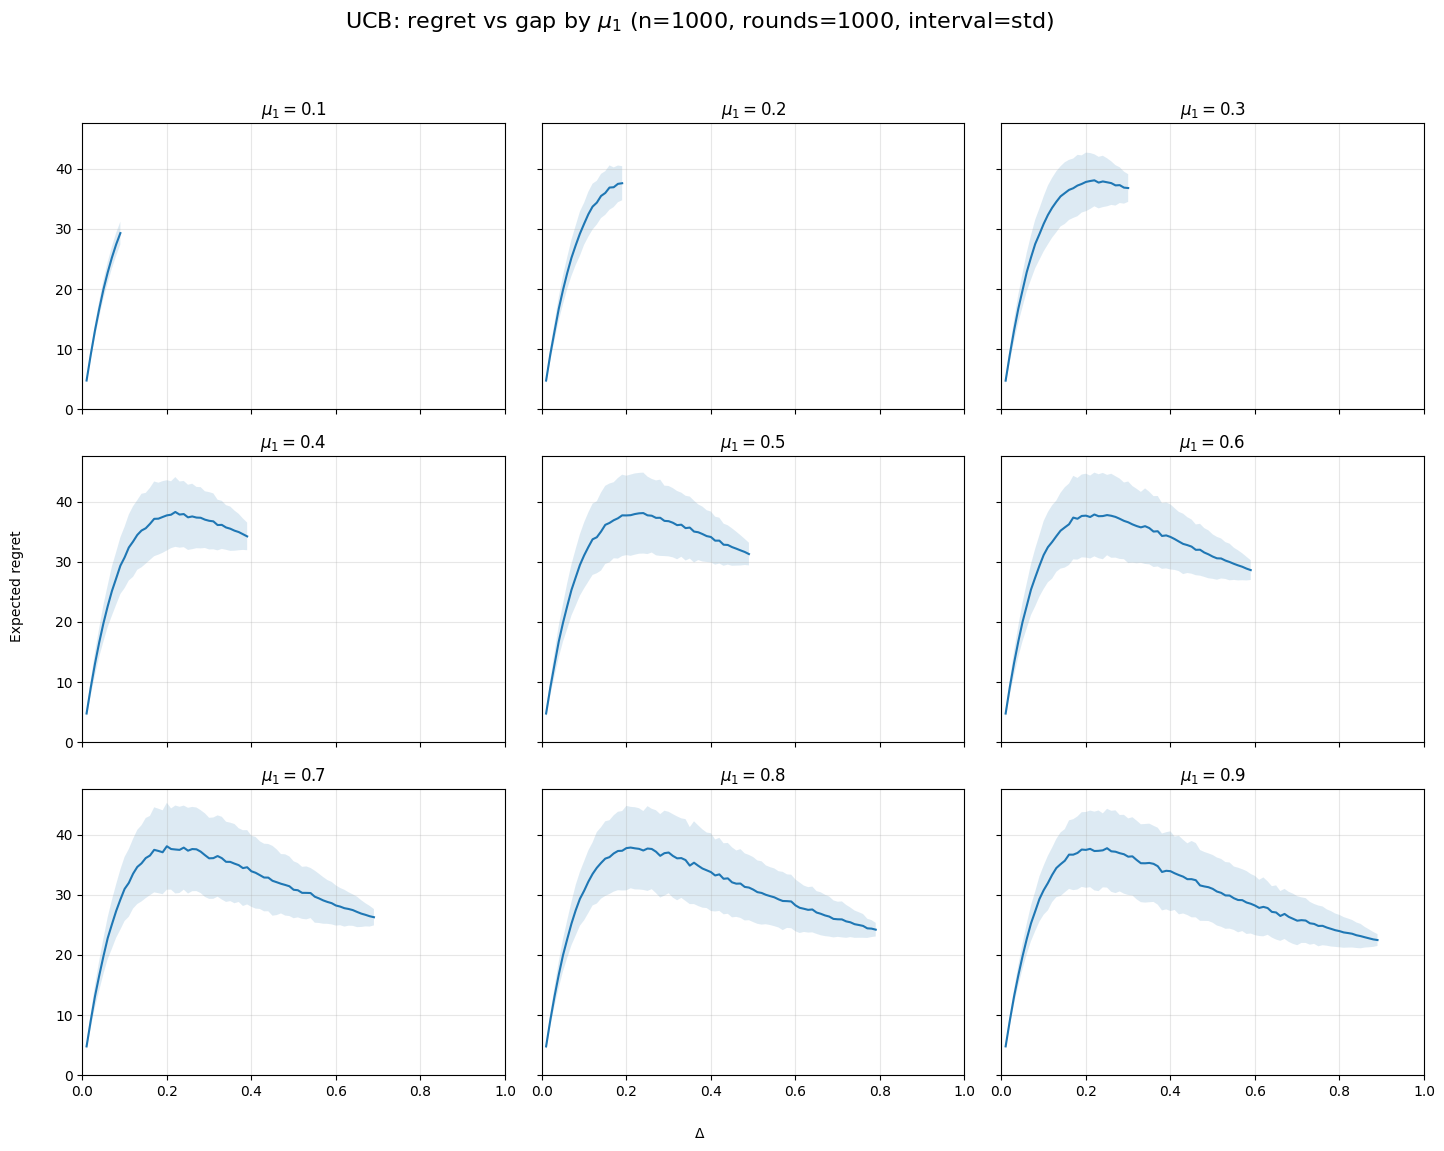

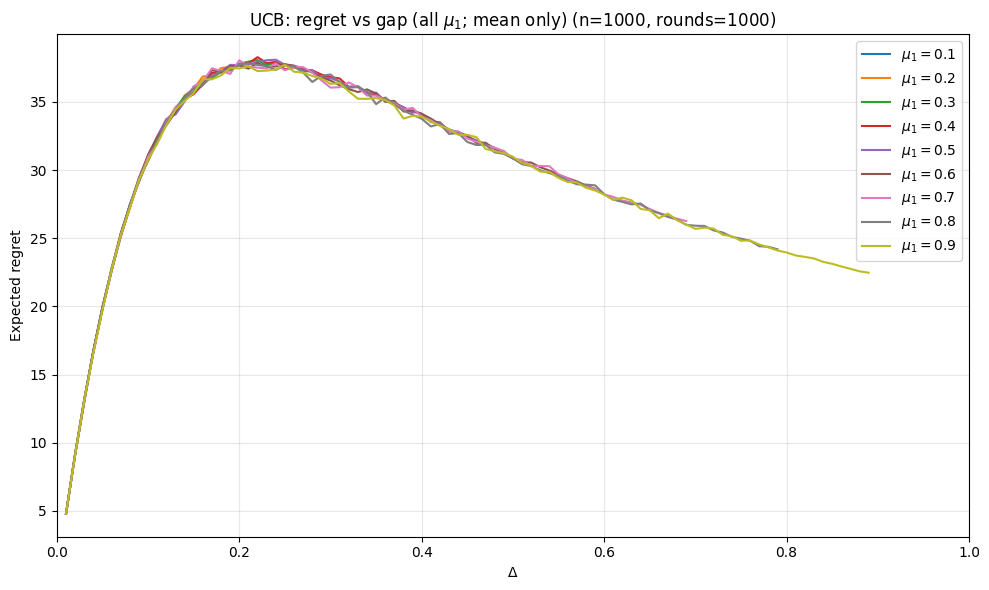

In [10]:
# =========================
# Plot 1: fixed subplots (3x3), each mu1 with interval
# =========================
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.reshape(-1)

# compute a common y-limit for fair comparison
global_ymax = 0.0
for mu_1 in mu1_grid:
    stats = aggregate_for_mu1(regrets, float(mu_1), interval=interval)
    if stats is not None:
        global_ymax = max(global_ymax, float(np.max(stats["hi"])))
global_ymax = max(global_ymax, 1e-9)

for idx, mu_1 in enumerate(mu1_grid):
    ax = axes[idx]
    stats = aggregate_for_mu1(regrets, float(mu_1), interval=interval)
    if stats is None:
        ax.axis("off")
        continue

    x, y = stats["deltas"], stats["mean"]
    lo, hi = stats["lo"], stats["hi"]

    ax.plot(x, y)
    ax.fill_between(x, lo, hi, alpha=0.15)
    ax.set_title(rf"$\mu_1={mu_1:.1f}$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, global_ymax * 1.05)
    ax.grid(True, alpha=0.3)

# global labels
fig.suptitle(rf"UCB: regret vs gap by $\mu_1$ (n={n_332}, rounds={rounds_332}, interval={interval})", fontsize=16)
fig.text(0.5, 0.04, r"$\Delta$", ha="center")
fig.text(0.04, 0.5, "Expected regret", va="center", rotation="vertical")
plt.tight_layout(rect=[0.06, 0.06, 1, 0.95])
plt.show()

# =========================
# Plot 2: combined comparison (all mu1), mean only (no interval)
# =========================
plt.figure(figsize=(10, 6))
for mu_1 in mu1_grid:
    stats = aggregate_for_mu1(regrets, float(mu_1), interval="std")  # interval irrelevant
    if stats is None:
        continue
    plt.plot(stats["deltas"], stats["mean"], label=rf"$\mu_1={mu_1:.1f}$")

plt.xlim(0, 1)
plt.xlabel(r"$\Delta$")
plt.ylabel("Expected regret")
plt.title(rf"UCB: regret vs gap (all $\mu_1$; mean only) (n={n_332}, rounds={rounds_332})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **Observation and Explanation:**

> **📌1. $\max\limits_{\Delta \in (0,R_n]} R_n(\mu_1, \Delta)$ is always being around 0.2 for $\mu_1 \ge 0.2$**
>
> we observed a **"first increase then drop after around $\Delta = 0.2$"** trend in all the occasions where $\mu_1 \ge 0.2$, here is our simple explanation:
> 
> Remember that $R_n = \sum_{i=1}^k \Delta_i\mathbb{E}[T_i(n)]$, in our specific double-arms case, $R_n = \Delta \cdot \mathbb{E}[T_2(n)]$.
>
> So, the case is that:
>
>- (a) when $\Delta$ is small, it's hard for the algorithm to differentiate the two arms, thus $\mathbb{E}[T_2(n)]$ would be large, however, if $\Delta \rightarrow 0$, then $R_n \rightarrow 0$, thus the regret won't be very large at this stage. But as $\Delta$ increase while it's still hard for the algorithm to detect the suboptimal one quickly, then $R_n$ will increase, this explain the monotonically increasing phase of $\Delta \le 0.2$.
>
> - (b) when $\Delta$ is sufficiently large, then the algorithm can easily detect the suboptimal one, thus $\mathbb{E}[T_2(n)]$ will be small, thus $R_n$ decrease as $\Delta$ keep increasing when $\Delta \ge 0.2$
>
> Thus, when the gap is neither sufficiently small to be neglected nor large enough to be distinguished, which is $\Delta \approx 0.2$, the regret $R_n$ achieves its maximum.
>
> Another explanation can derive from 3.2.3 Thr, by whose proof we have $\mathbb{E}[T_2(n)] \le 3 + \frac{16 \log(n)}{\Delta^2}$,then we have $\mathbb{E}[T_2(n)] \le \min\left( n, 3 + \frac{16\log(n)}{\Delta^2}   \right)$, thus $$R_n = \Delta \cdot \mathbb{E}[T_2(n)] \le \min\left( \Delta n, 3\Delta + \frac{16\log(n)}{\Delta}\right)$$
> then if $n$ is significantly larger than 3, we have 
>$$
>R_n \lesssim  \min\left( \Delta n,\frac{16\log(n)}{\Delta}\right)
>$$
> this upper bound can obviously explain the behaviour of $R_n$ around $\Delta=0.2$, when $\Delta$ is small, $ \min\left( \Delta n,\frac{16\log(n)}{\Delta}\right) =\Delta n$, which increase as $\Delta$ grows, then as $\Delta$ is sufficiently large, $ \min\left( \Delta n,\frac{16\log(n)}{\Delta}\right)=\frac{16\log(n)}{\Delta}$, which decrease as $\Delta$ become larger.

> **📌Remark: Easy bandits are those where the suboptimality gaps are large or very small**

# **4. Further Discussion**







## **4.1 A "concave-like" regret upper bound w.r.t $\Delta$ for UCB**

since neither of the bounds proved by Thr 3.2.3 nor Thr 3.2.5 sketches the concave-like (w.r.t $\Delta$) shape (though it's actually not strictly concave) of the regret that we spoted in 3.3.2, we wonder that if there is an upper-bound that sucessfully sketch this shape and if lucky , is tighter than the former two bounds. 

By the proof of Thr 3.2.3, for $\forall i \in [k]$ s.t. $\Delta_i >0$, we have:

$$
\mathbb{E}[T_i(n)] \le 3 + \frac{16\log(n)}{\Delta_i^2}
$$

and it's obvious that $\mathbb{E}[T_i(n)] \le n$, hence we have

$$
\mathbb{E}[T_i(n)] \le \min\left\{n,3 + \frac{16\log(n)}{\Delta_i^2}\right\} 
$$

then

$$
\begin{align}
R_n &= \sum_{i: \Delta_i >0} \mathbb{E}[T_i(n)]\Delta_i \\
& \le \sum_{i: \Delta_i >0}\Delta_i\min\left\{n,3 + \frac{16\log(n)}{\Delta_i^2}\right\} \\
&= \sum_{i: \Delta_i >0}\min\left\{n\Delta_i,3\Delta_i + \frac{16\log(n)}{\Delta_i}\right\} \\
&\le \min\left\{n\sum_{i: \Delta_i >0}\Delta_i,\sum_{i: \Delta_i >0}\left[3\Delta_i + \frac{16\log(n)}{\Delta_i}\right]\right\} \\
&= \min\left\{n\sum_{i: \Delta_i >0}\Delta_i,3\sum_{i: \Delta_i >0}\Delta_i + \sum_{i: \Delta_i >0}\frac{16\log(n)}{\Delta_i}\right\} \\
\end{align}
$$

this is tighter than the bound in Thr 3.2.3 when $\exists \Delta_i \rightarrow 0$.

and when $n \gg 3$, we have

$$
R_n \lesssim \min\left\{n\sum_{i: \Delta_i >0}\Delta_i,16\log(n)\sum_{i: \Delta_i >0}\frac{1}{\Delta_i}\right\} 
$$

when $k=2$, suppose $\mu_1$ is the optimal arm, and $\Delta_2 = \Delta$ where $\Delta \in (0,\mu_1]$, then 

$$
R_n \le \min\left\{n\Delta,3\Delta + \frac{16\log(n)}{\Delta}\right\}
$$

to check this, we plot this $R_n$ with the result of experiment 3.3.2, 

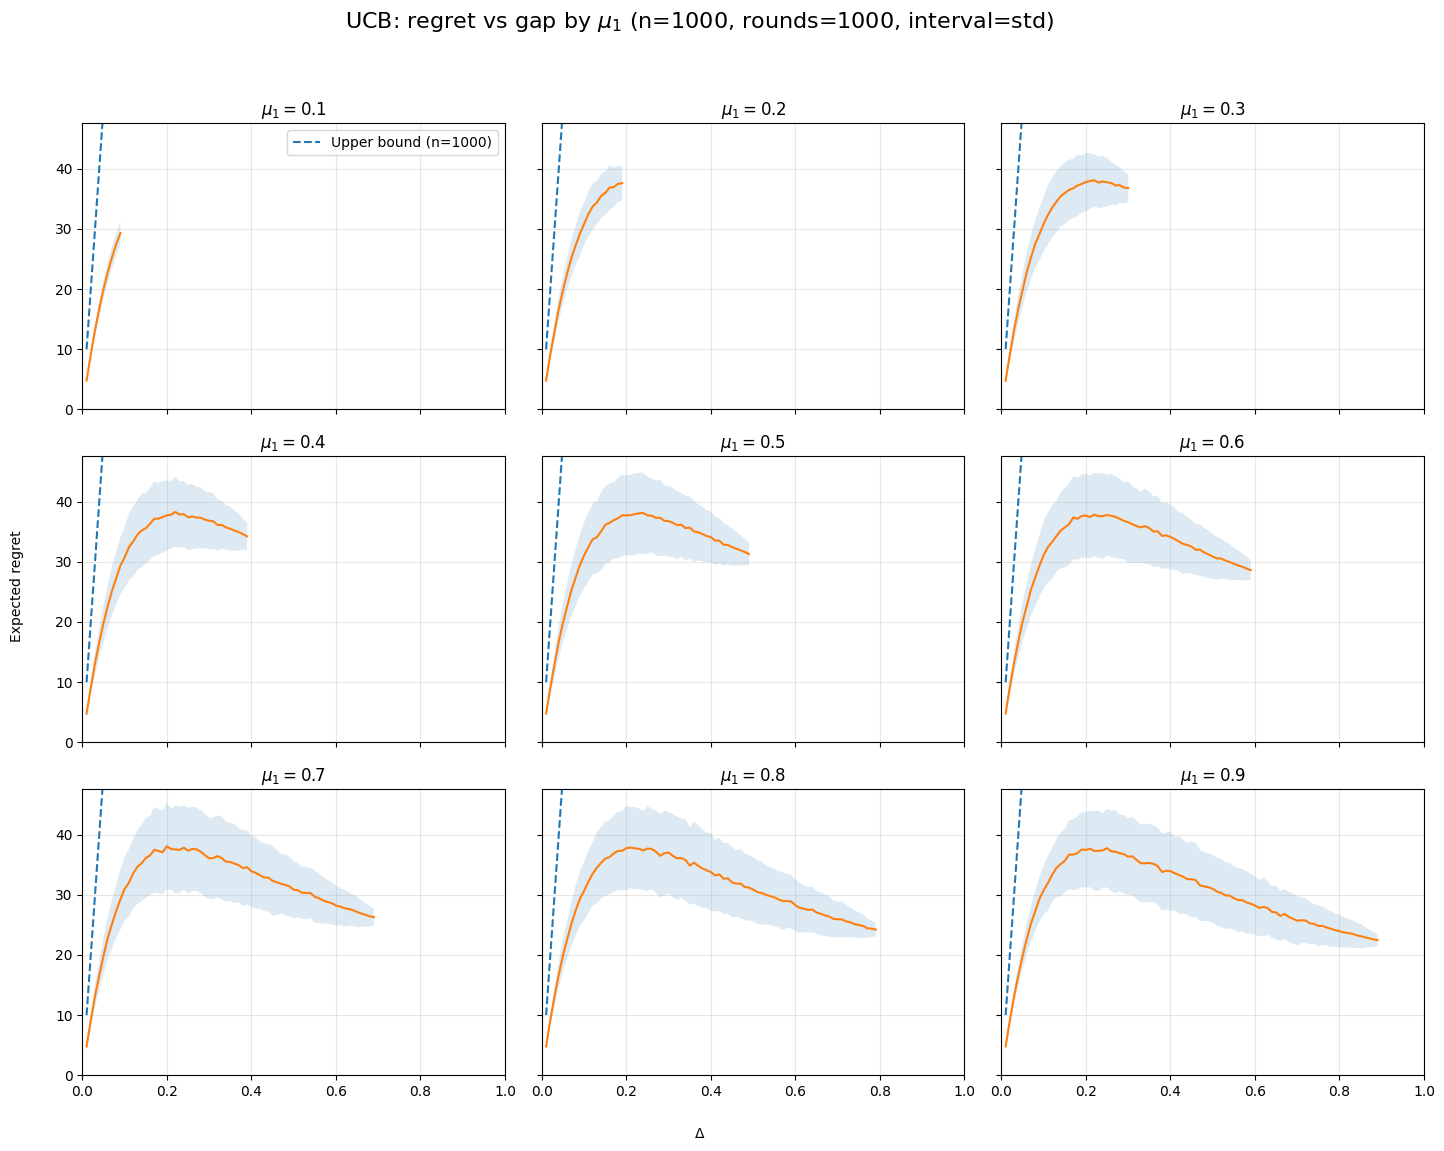

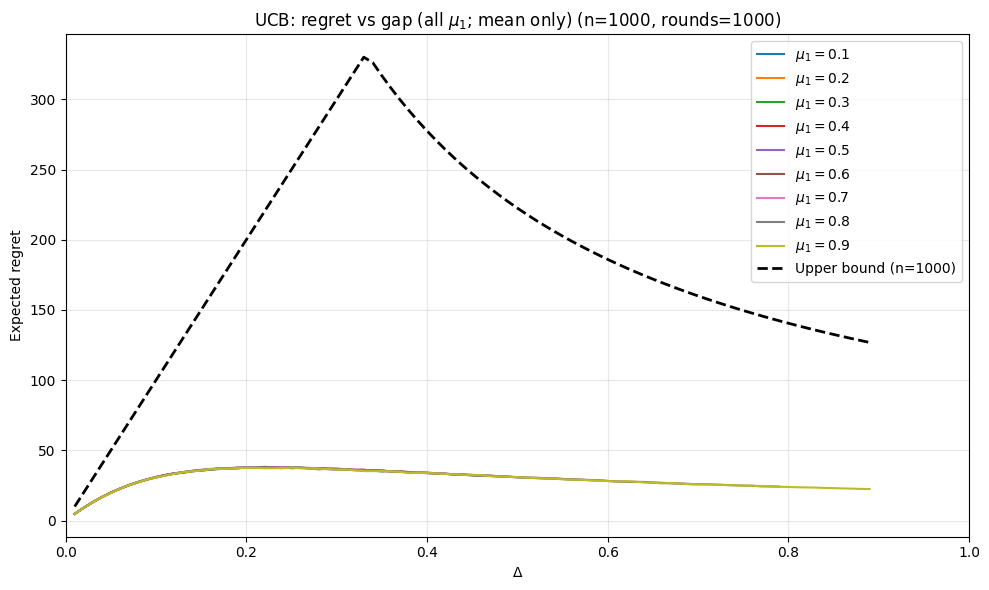

In [11]:
# upper bound (n = 1000)
n_bound = 1000

def ucb_upper_bound(delta):
    delta = np.maximum(delta, 1e-8)  # avoid division by zero
    term1 = n_bound * delta
    term2 = 3 * delta + 16 * np.log(n_bound) / delta
    return np.minimum(term1, term2)


# =========================
# Plot 1: fixed subplots (3x3), each mu1 with interval
# =========================
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.reshape(-1)

# compute a common y-limit for fair comparison
global_ymax = 0.0
for mu_1 in mu1_grid:
    stats = aggregate_for_mu1(regrets, float(mu_1), interval=interval)
    if stats is not None:
        global_ymax = max(global_ymax, float(np.max(stats["hi"])))
global_ymax = max(global_ymax, 1e-9)

for idx, mu_1 in enumerate(mu1_grid):
    ax = axes[idx]
    stats = aggregate_for_mu1(regrets, float(mu_1), interval=interval)
    if stats is None:
        ax.axis("off")
        continue

    x, y = stats["deltas"], stats["mean"]
    ub = ucb_upper_bound(x)
    ax.plot(x, ub, linestyle="--", linewidth=1.5, label="Upper bound (n=1000)")
    lo, hi = stats["lo"], stats["hi"]
    if idx == 0:
       ax.legend()
    ax.plot(x, y)
    ax.fill_between(x, lo, hi, alpha=0.15)
    ax.set_title(rf"$\mu_1={mu_1:.1f}$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, global_ymax * 1.05)
    ax.grid(True, alpha=0.3)

# global labels
fig.suptitle(rf"UCB: regret vs gap by $\mu_1$ (n={n_332}, rounds={rounds_332}, interval={interval})", fontsize=16)
fig.text(0.5, 0.04, r"$\Delta$", ha="center")
fig.text(0.04, 0.5, "Expected regret", va="center", rotation="vertical")
plt.tight_layout(rect=[0.06, 0.06, 1, 0.95])
plt.show()

# =========================
# Plot 2: combined comparison (all mu1), mean only (no interval)
# =========================
plt.figure(figsize=(10, 6))
for mu_1 in mu1_grid:
    stats = aggregate_for_mu1(regrets, float(mu_1), interval="std")  # interval irrelevant
    if stats is None:
        continue
    plt.plot(stats["deltas"], stats["mean"], label=rf"$\mu_1={mu_1:.1f}$")
# common delta grid (use last stats)
delta_grid = stats["deltas"]
ub = ucb_upper_bound(delta_grid)
plt.plot(delta_grid, ub, linestyle="--", linewidth=2, color="black",
         label="Upper bound (n=1000)")
plt.xlim(0, 1)
plt.xlabel(r"$\Delta$")
plt.ylabel("Expected regret")
plt.title(rf"UCB: regret vs gap (all $\mu_1$; mean only) (n={n_332}, rounds={rounds_332})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## **4.2 The distribution of $\Delta$**



It has been observed in 3.3.2 that the gap among arms' reward is crutial for the regret, then we are curious about how the algorithm behaves under different distribution of $\Delta = (\Delta_1, \Delta_2, \cdots, \Delta_k)$, since we'd like to try with arm number $k >2$, thus the first step is to reduce the dimention of $\Delta$ while keeping information of major concern via multiple feature engineering methods.

> **📌Claim: What affects the algorithm performance isn't the absolute value of $\mu_i$, it's the gap $\Delta_i$**

> 📌 **Our goal in this part is to create an index $\delta$ that describe the distro of $\Delta$, then prove an upper bound for UCB that only takes $\delta$ rather than $\Delta_i$ as parameter** 

### **4.1.1 How to decribe a $\Delta = (\Delta_1, \Delta_2, \cdots, \Delta_k)$**

> **📌 without loss of generalty, fix the first arm to be the best arm, then $\Delta_1 = 0$**

We firstly come up with some easy ways like:

- (1) $\min\limits_{i \in [k]}\Delta_i$
- (2) $\frac{1}{k}\sum_{i=1}^k \Delta_i$

However, there are some flaws of these simple features,

for (1), let $\Delta >0$ be a constant that is neither very large s.t the algorithm can imediately differentiate it from the best arm, nor very small s.t. its regret can be ommited, and  $\Delta = (0, \Delta, )$

## **4.3 what if $X_i \sim subG(\sigma_i)$ with $\sigma_i \ne \sigma_j (i \ne j)$**

Suppose 

$$
\mu_i := \mathbb{E}[X_{i,t}]
$$

then the reward of each arm that one might get at time step $t$ is:

$$
\vec{X}_t - \vec{\mu} := (X_{1,t} - \mu_1, X_{2,t} - \mu_2, X_{3,t}- \mu_3, \cdots, X_{k,t}- \mu_k) \overset{\text{i.i.d.}}{\sim} subG(\vec{\sigma})
$$

where:

- $X_{i,t}$'s $(i = 1,\cdots, n)$ are mutually independent 
- $\vec{\mu}  = (\mu_1, \mu_2, \cdots, \mu_k)\in \mathbb{R}^k$
- $\vec{\sigma} = (\sigma_1, \sigma_2, \cdots,\sigma_k) \in \mathbb{R}^k_{\ge 0}$ is a fixed real vector 

Say, $A_t = i$, then the reward at time step $t$ can be defined as:

$$
f(\vec{X}_t, A_t) = X_{i,t}
$$


# **Appendix**

### **1. Proof of 3.2.3 Thr**

![img1](materials/20260219_212643.png)
![img2](materials/20260219_212653.png)
![img3](materials/20260219_212701.png)
![img4](materials/20260219_212710.png)
![img5](materials/20260219_212717.png)
![img6](materials/20260219_212725.png)
![img7](materials/20260219_212733.png)
![img8](materials/20260219_212740.png)


### **2. Proof of 3.2.5 Thr**

![img3.2.5](materials/20260219_213504.png)